# Fixed points in the GLV system
The system
$$
\dot{x}_i = x_i \left(1- x_i + \sum_j A_{ij}\alpha_{ij}x_j\right)
$$

always admits $x = 0$ as a fixed point.
The other fixed point is given by:
$$
1-x_i^* + \sum_j A_{ij}\alpha_{ij}x_j^* = 0 \\
x_i^* = 1 + \sum_j W_{ij} x_j^*
$$
that in vectorial form results in:
$$
x^* = (1-W)^{-1}1
$$
thus when the matrix $(1-W)$ is not invertible the surviving species explode to infinity

In [15]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import networkx as nx

def fixed_point_lcp_sparse(M, tol=1e-5, max_iter=3000):
    """Algebraic LCP solver using Projected Damped Jacobi for sparse matrices."""
    N = M.shape[0]
    x = np.ones(N)
    damping = 0.1 
    
    for _ in range(max_iter):
        x_target = 1.0 + M.dot(x)
        x_target[x_target < 0] = 0.0 
        
        diff = x_target - x
        if np.max(np.abs(diff)) < tol:
            return x_target
        x = x + damping * diff
    return x


In [27]:
# --- Parameters ---
N = 1000
C = 50        # Average degree
mu = -0.5     # Competitive regime (mu < 0) [cite: 82]
sigma = 0   # Interaction heterogeneity [cite: 73]

# --- 1. Generate Exponential Degree Sequence ---
# In the rescaled theory, g = k/C[cite: 117]. 
# So we sample g from exp(1) and set k = g * C.
# --- 1. Generate Degree Sequence ---
# Sampling g ~ exp(1), then k = g * C [cite: 231, 232, 309]
degrees = np.random.exponential(scale=C, size=N).round().astype(int)

# Ensure the sum is even for the configuration model [cite: 66]
if sum(degrees) % 2 != 0:
    degrees[0] += 1

# --- 2. Build Network using NetworkX ---
print(f"Building network with NetworkX (N={N})...")
# create_using=nx.Graph() automatically handles symmetry and removes self-loops/multiedges
G = nx.configuration_model(degrees, create_using=nx.Graph())
G.remove_edges_from(nx.selfloop_edges(G))

# Convert to sparse matrix immediately
A = nx.to_scipy_sparse_array(G, format='csr')

# --- 3. Compute Fixed Point ---
# M = A_ij * alpha_ij [cite: 63, 65]
z = np.random.normal(0, 1, A.nnz)
alpha_values = (mu / C) + (sigma / np.sqrt(C)) * z
M = A.astype(float)
M.data *= alpha_values

steady_state = fixed_point_lcp_sparse(M)

Building network with NetworkX (N=1000)...


Solving fixed point...


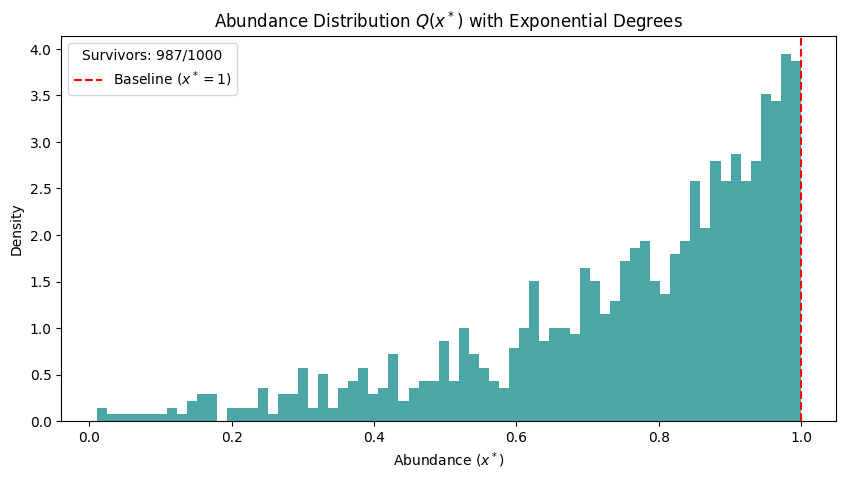

In [28]:
# --- 4. Solve and Visualize ---
print("Solving fixed point...")
steady_state = fixed_point_lcp_sparse(M)
survivors = steady_state[steady_state > 0]

plt.figure(figsize=(10, 5))
# Plotting the abundance distribution Q(x*) [cite: 268, 270]
plt.hist(survivors, bins=70, density=True, color='teal', alpha=0.7)
plt.axvline(1.0, color='red', linestyle='--', label='Baseline ($x^*=1$)')
plt.title(r"Abundance Distribution $Q(x^*)$ with Exponential Degrees")
plt.xlabel("Abundance ($x^*$)")
plt.ylabel("Density")
plt.legend(title=f"Survivors: {len(survivors)}/{N}")
plt.show()